In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

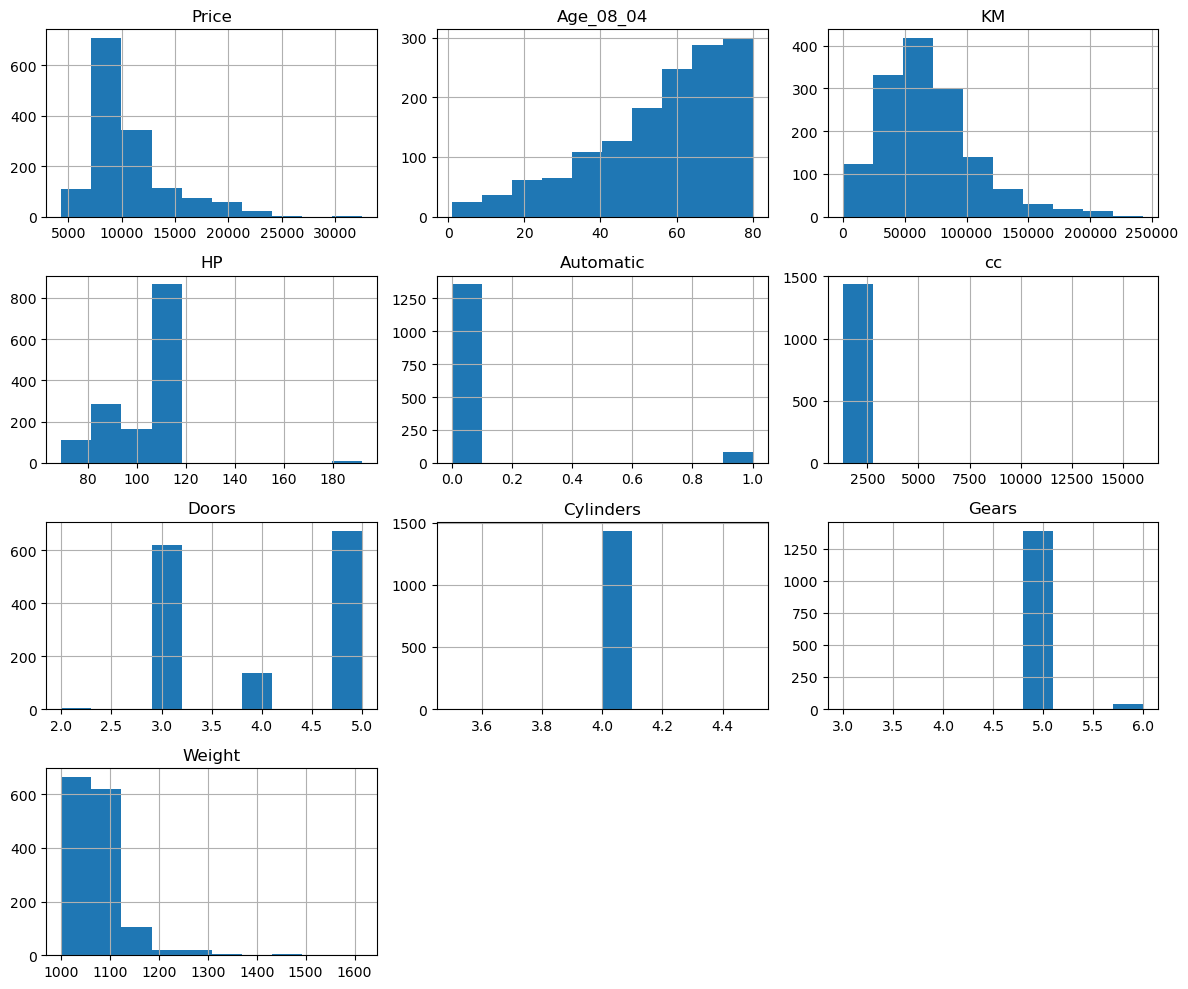

In [7]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

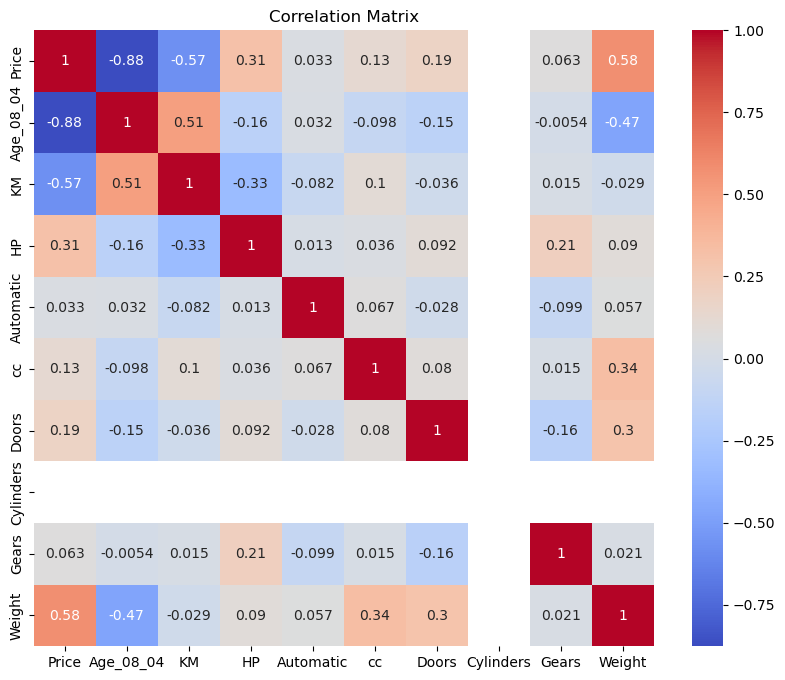

In [8]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[int]) 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [10]:
df=df.astype(int)

In [11]:
x = df.drop('Price', axis=1)
y = df['Price']

In [12]:
x.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,90,0,2000,3,4,5,1165,1,0
1,23,72937,90,0,2000,3,4,5,1165,1,0
2,24,41711,90,0,2000,3,4,5,1165,1,0
3,26,48000,90,0,2000,3,4,5,1165,1,0
4,30,38500,90,0,2000,3,4,5,1170,1,0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [15]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [16]:
# Model 1 – Full Multiple Linear Regression(Add constant for intercept)
X_train_sm = sm.add_constant(X_train)
model1 = sm.OLS(y_train, X_train_sm).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     762.7
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:30:03   Log-Likelihood:                -9863.2
No. Observations:                1148   AIC:                         1.975e+04
Df Residuals:                    1137   BIC:                         1.980e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age_08_04         -120.8305      2.887  

In [17]:
# Model 2 – Reduced Model (Remove Insignificant Variables) Remove variables with p-value > 0.05.
X_train2 = X_train.drop(['Fuel_Type_Diesel'], axis=1)
X_train2 = sm.add_constant(X_train2)

model2 = sm.OLS(y_train, X_train2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     848.2
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:30:03   Log-Likelihood:                -9863.2
No. Observations:                1148   AIC:                         1.975e+04
Df Residuals:                    1138   BIC:                         1.980e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age_08_04         -120.8762      2.874  

In [18]:
# Model 3 – Reduced Model (Remove Insignificant Variables) Remove variables with p-value > 0.05.
X_train3 = X_train.drop(['Doors'], axis=1)
X_train3 = sm.add_constant(X_train3)

model2 = sm.OLS(y_train, X_train3).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     846.6
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:30:03   Log-Likelihood:                -9864.1
No. Observations:                1148   AIC:                         1.975e+04
Df Residuals:                    1138   BIC:                         1.980e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Age_08_04         -120.9350      2.887  

In [19]:
#Standardized Model (Sklearn)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred3 = lr.predict(X_test_scaled)

In [20]:
# Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [21]:
#Model Evaluation
def evaluate(y_test, y_pred):
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [22]:
X_test_sm = sm.add_constant(X_test)
y_pred1 = model1.predict(X_test_sm)

print("Model 1 Performance")
evaluate(y_test, y_pred1)

Model 1 Performance
R2 Score: 0.8348888040611077
MAE: 990.8872739193947
RMSE: 1484.265415329654


In [23]:
print("Model 3 Performance")
evaluate(y_test, y_pred3)

Model 3 Performance
R2 Score: 0.8348888040611081
MAE: 990.887273919397
RMSE: 1484.265415329652


In [24]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Performance")
evaluate(y_test, y_pred_ridge)

Ridge Performance
R2 Score: 0.8350462635431563
MAE: 990.8591771287419
RMSE: 1483.5575063081635


In [25]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Performance")
evaluate(y_test, y_pred_lasso)

Lasso Performance
R2 Score: 0.8349116135580271
MAE: 990.9001968731633
RMSE: 1484.1628889184242


Final Conclusion

Age and KM significantly decrease price.

HP and Weight increase price.

Reduced model performs similarly with fewer variables.

Ridge improves stability.

Lasso removes insignificant features.

Best model selected based on highest R² and lowest RMSE.

1.What is Normalization & Standardization and how is it helpful?

Normalization scales data between 0 and 1 using Min-Max scaling, while Standardization transforms data to have mean 0 and standard deviation 1 using Z-score scaling. Scaling is helpful because it prevents large-scale features from dominating the model and is especially important for regularization techniques like Ridge and Lasso.

2.What techniques can be used to address multicollinearity in multiple linear regression?

To address multicollinearity, we can remove highly correlated variables using correlation matrix or VIF, use Ridge regression to shrink coefficients, apply Lasso for feature selection, or use PCA to transform correlated variables into uncorrelated components.